<a href="https://www.kaggle.com/code/omborse771924/sih-2026-problem-statements-analysis-70-accuracy?scriptVersionId=345801355" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshyakeshwani/sih-2026-problem-statements/README.md
/kaggle/input/datasets/lakshyakeshwani/sih-2026-problem-statements/sih_2026_problem_statements.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lakshyakeshwani/sih-2026-problem-statements/sih_2026_problem_statements.csv')

In [3]:
df.head()

,Unnamed: 0,Organization,Problem Statement Title,Category,PS Number,Theme,Deadline for Idea Submission,Details
0,0,Ministry of Development of North Eastern Regio...,AI-Based early warning and landslide Risk Moni...,Software,SIH26001,Disaster Management,20 September 2026,Background: The North Eastern Region (NER) fre...
1,1,Ministry of Development of North Eastern Regio...,Al-Based Smart Logistics and Accessibility Int...,Software,SIH26002,Smart Automation,20 September 2026,Background: The North Eastern Region (NER) fac...
2,2,Ministry of Development of North Eastern Regio...,AI-Based Cognitive Gaming and Memory Assistanc...,Software,SIH26003,Space Technology,20 September 2026,Background: The North Eastern Region (NER) is ...
3,3,Ministry of Development of North Eastern Regio...,Al-Assisted Early Detection System for Osteoar...,Hardware,SIH26004,Space Technology,20 September 2026,Background: Osteoarthritis (OA) is one of the ...
4,4,Ministry of Development of North Eastern Regio...,Solar-Powered Smart Mini Cold Storage System f...,Hardware,SIH26005,Smart Vehicles,20 September 2026,Background: The North Eastern Region (NER) pro...


In [4]:
df.tail()

,Unnamed: 0,Organization,Problem Statement Title,Category,PS Number,Theme,Deadline for Idea Submission,Details
221,221,AICTE,Student Innovation,Hardware,SIH26222,Smart Education,20 September 2026,Student Innovation-Submit your ideas to addres...
222,222,AICTE,Student Innovation,Hardware,SIH26223,Disaster Management,20 September 2026,Student Innovation-Disaster management include...
223,223,AICTE,Student Innovation,Hardware,SIH26224,Travel & Tourism,20 September 2026,"Student Innovation-Smart education,a concept t..."
224,224,AICTE,Student Innovation,Hardware,SIH26225,Heritage & Culture,20 September 2026,Student Innovation-Challenge your creative min...
225,225,AICTE,Student Innovation,Hardware,SIH26226,Space Technology,20 September 2026,Student Innovation-Space technology refers to ...


In [5]:
df.info

<bound method DataFrame.info of      Unnamed: 0                                       Organization  \
0             0  Ministry of Development of North Eastern Regio...   
1             1  Ministry of Development of North Eastern Regio...   
2             2  Ministry of Development of North Eastern Regio...   
3             3  Ministry of Development of North Eastern Regio...   
4             4  Ministry of Development of North Eastern Regio...   
..          ...                                                ...   
221         221                                              AICTE   
222         222                                              AICTE   
223         223                                              AICTE   
224         224                                              AICTE   
225         225                                              AICTE   

                               Problem Statement Title  Category PS Number  \
0    AI-Based early warning and landslide Risk Mo

In [6]:
df.describe

<bound method NDFrame.describe of      Unnamed: 0                                       Organization  \
0             0  Ministry of Development of North Eastern Regio...   
1             1  Ministry of Development of North Eastern Regio...   
2             2  Ministry of Development of North Eastern Regio...   
3             3  Ministry of Development of North Eastern Regio...   
4             4  Ministry of Development of North Eastern Regio...   
..          ...                                                ...   
221         221                                              AICTE   
222         222                                              AICTE   
223         223                                              AICTE   
224         224                                              AICTE   
225         225                                              AICTE   

                               Problem Statement Title  Category PS Number  \
0    AI-Based early warning and landslide Risk 

In [7]:
df.isnull()

,Unnamed: 0,Organization,Problem Statement Title,Category,PS Number,Theme,Deadline for Idea Submission,Details
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
221,False,False,False,False,False,False,False,False
222,False,False,False,False,False,False,False,False
223,False,False,False,False,False,False,False,False
224,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Unnamed: 0                      0
Organization                    0
Problem Statement Title         0
Category                        0
PS Number                       0
Theme                           0
Deadline for Idea Submission    0
Details                         0
dtype: int64

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
221    False
222    False
223    False
224    False
225    False
Length: 226, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Unnamed: 0', 'Organization', 'Problem Statement Title', 'Category',
       'PS Number', 'Theme', 'Deadline for Idea Submission', 'Details'],
      dtype='object')

## EDA

DATASET INFORMATION
Shape: (226, 8)

Columns:
['Unnamed: 0', 'Organization', 'Problem Statement Title', 'Category', 'PS Number', 'Theme', 'Deadline for Idea Submission', 'Details']

Duplicate rows: 0
Shape after removing duplicates: (226, 8)

NULL VALUES
Unnamed: 0                      0
Organization                    0
Problem Statement Title         0
Category                        0
PS Number                       0
Theme                           0
Deadline for Idea Submission    0
Details                         0
dtype: int64

Remaining null values:
0


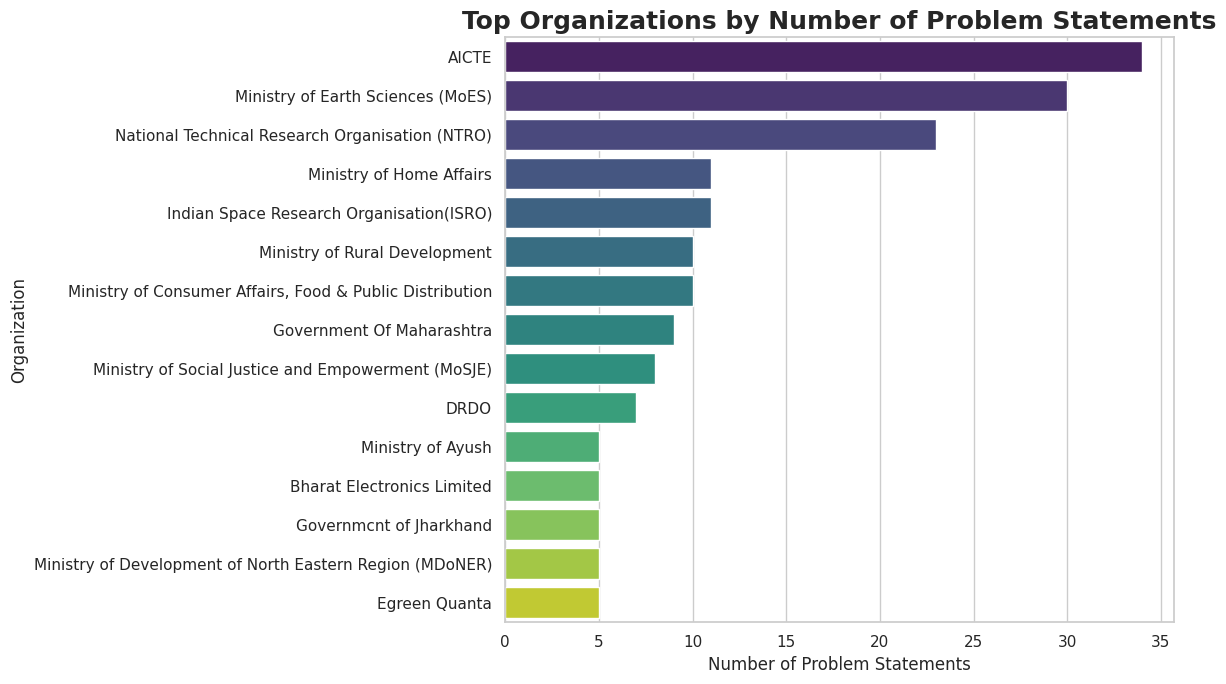

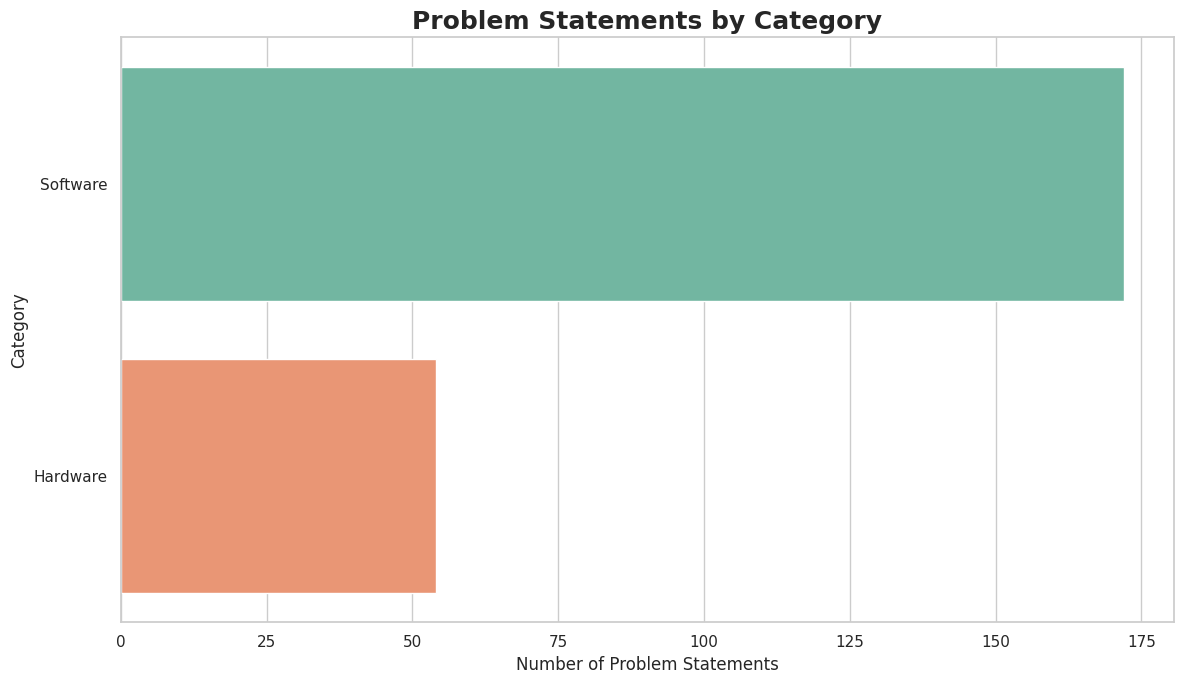

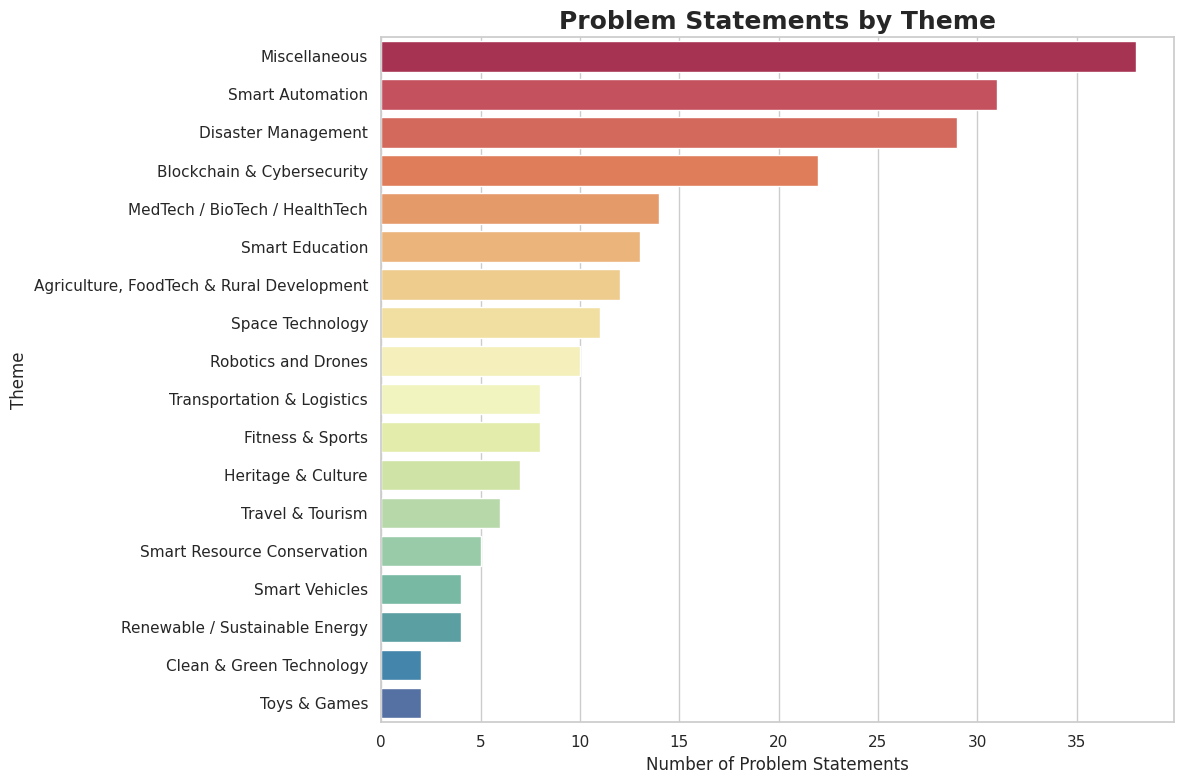

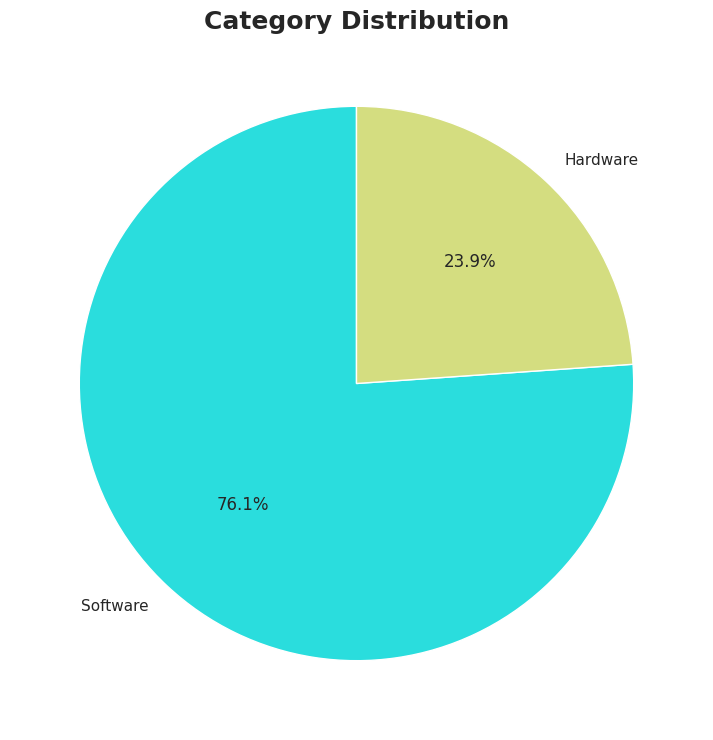

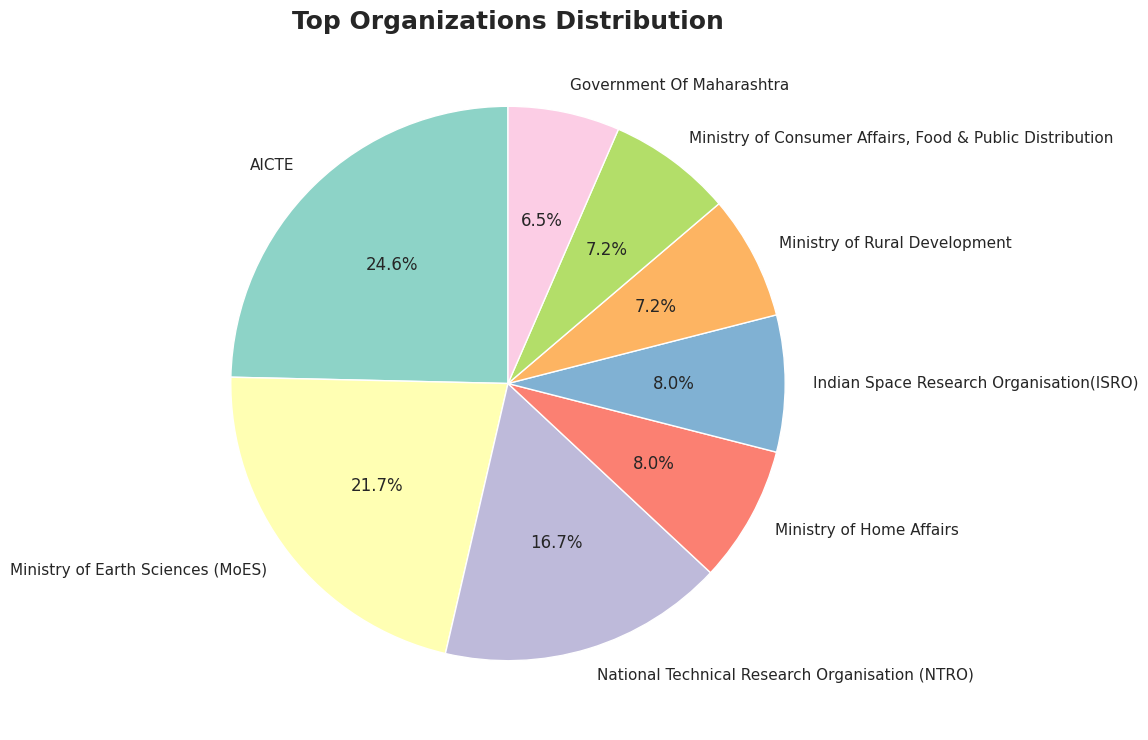

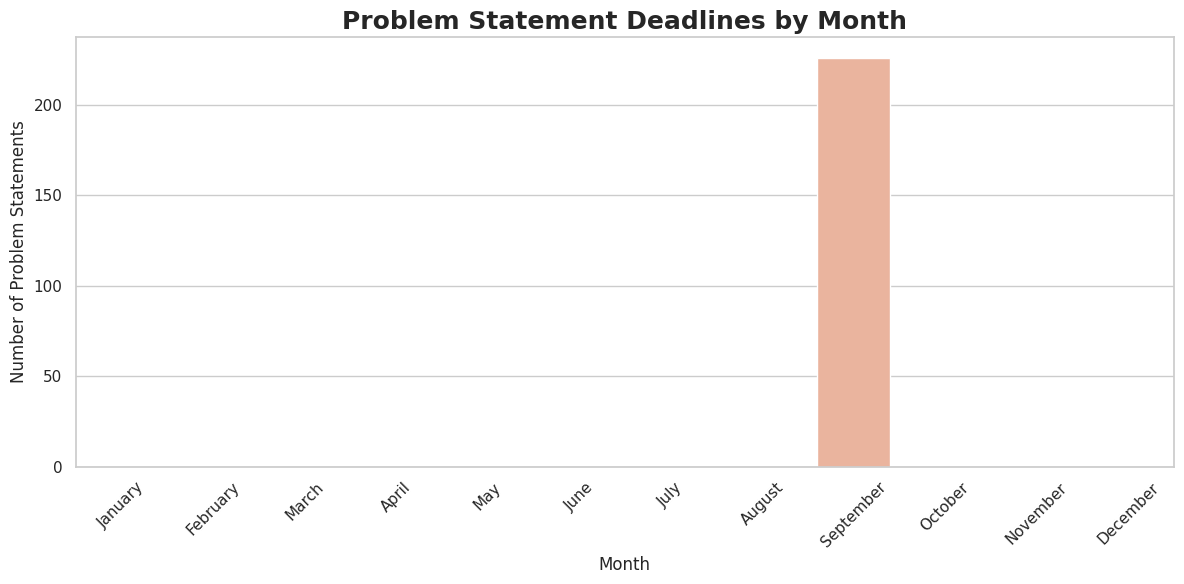

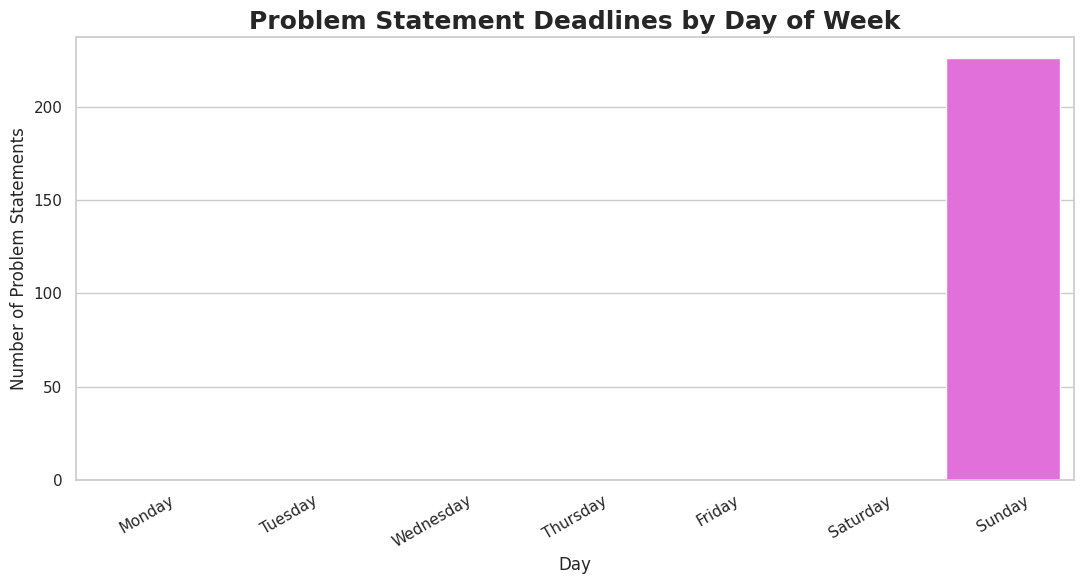

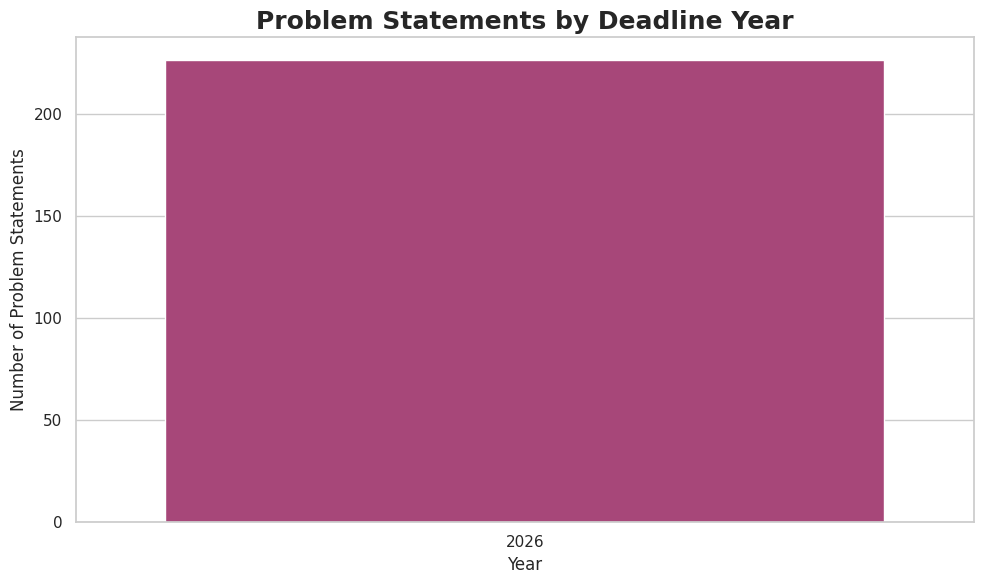

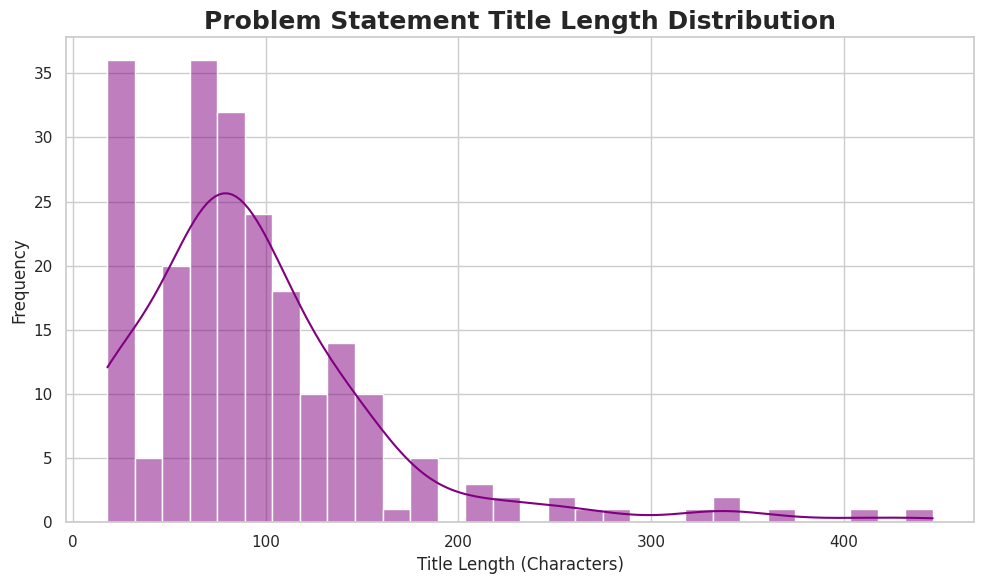

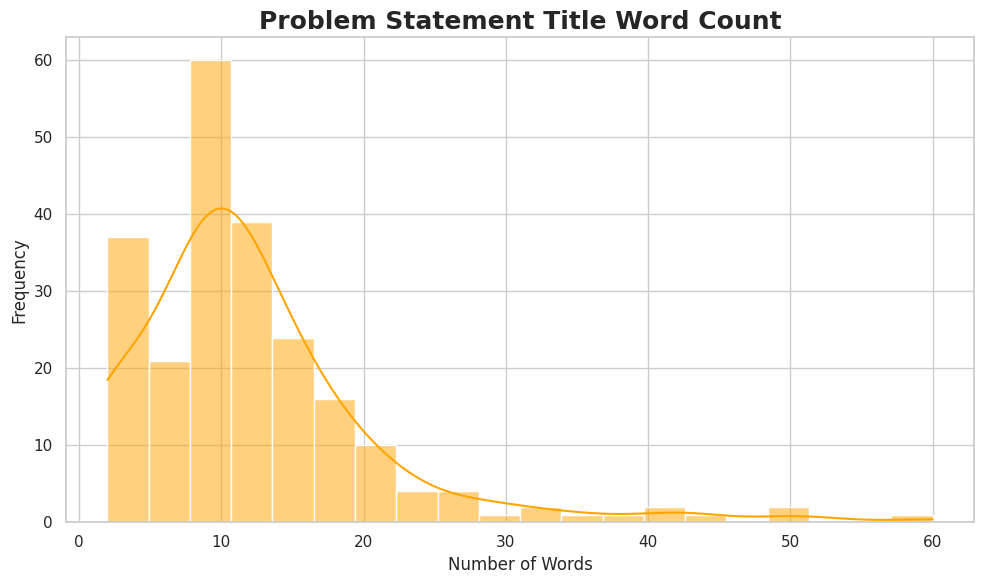

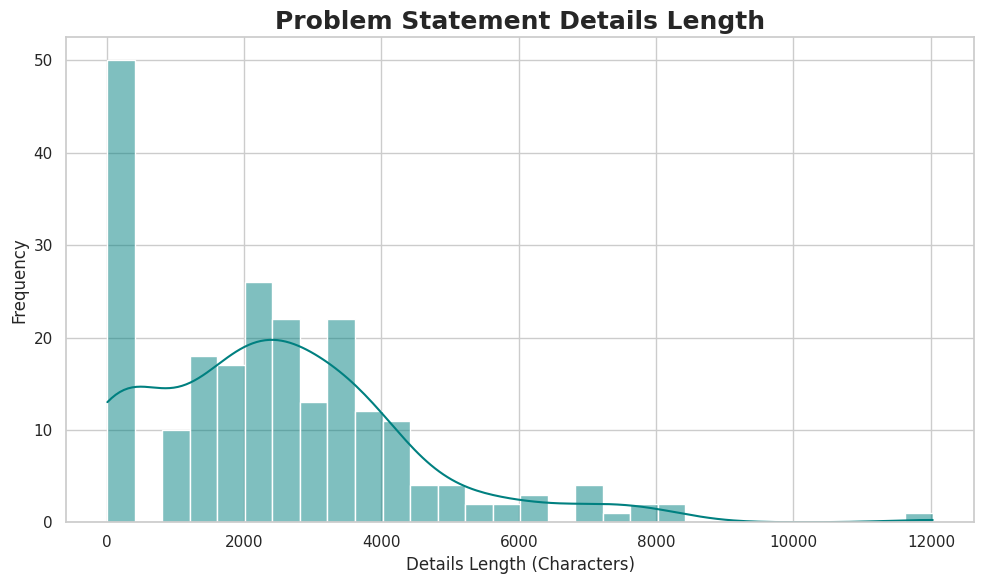

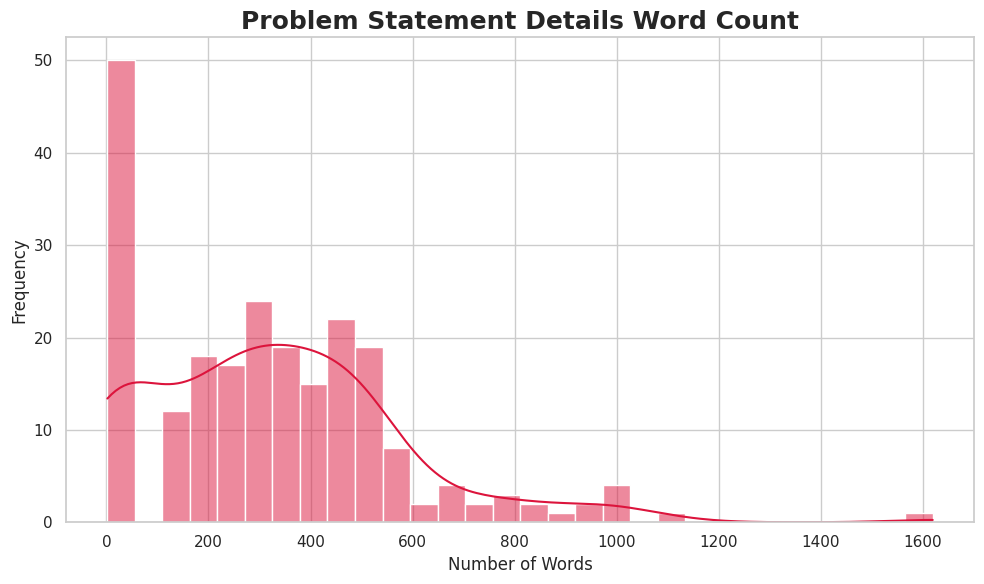

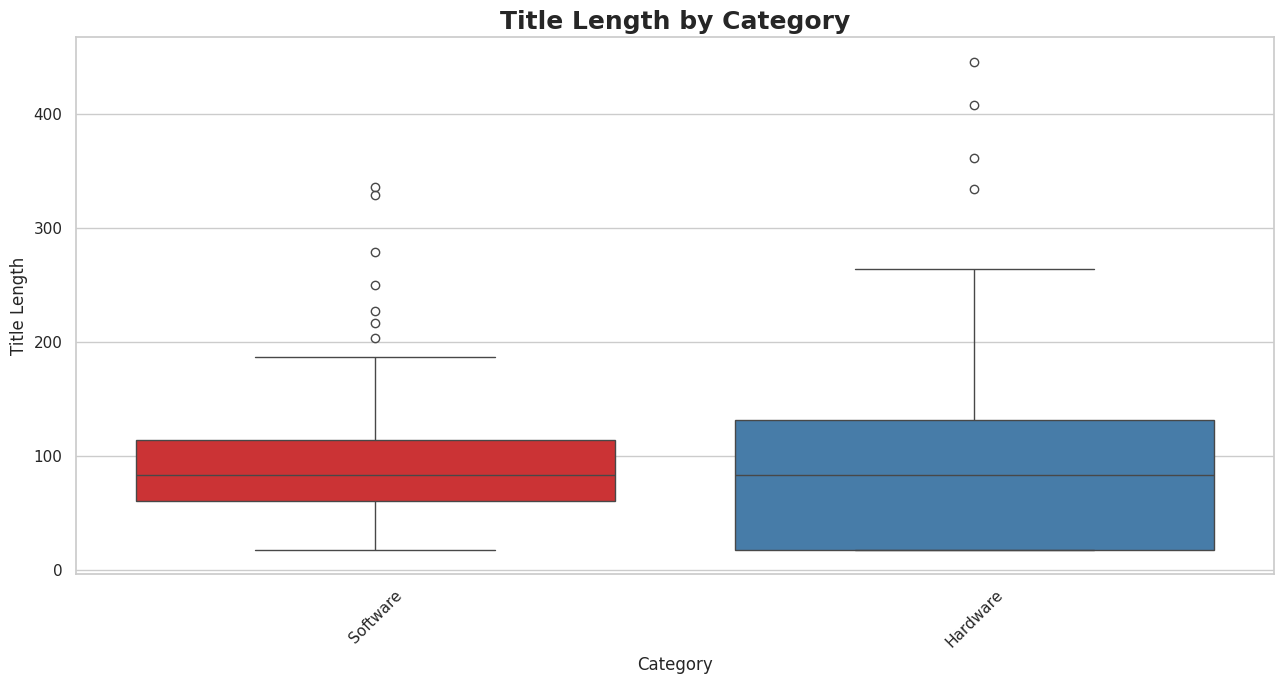

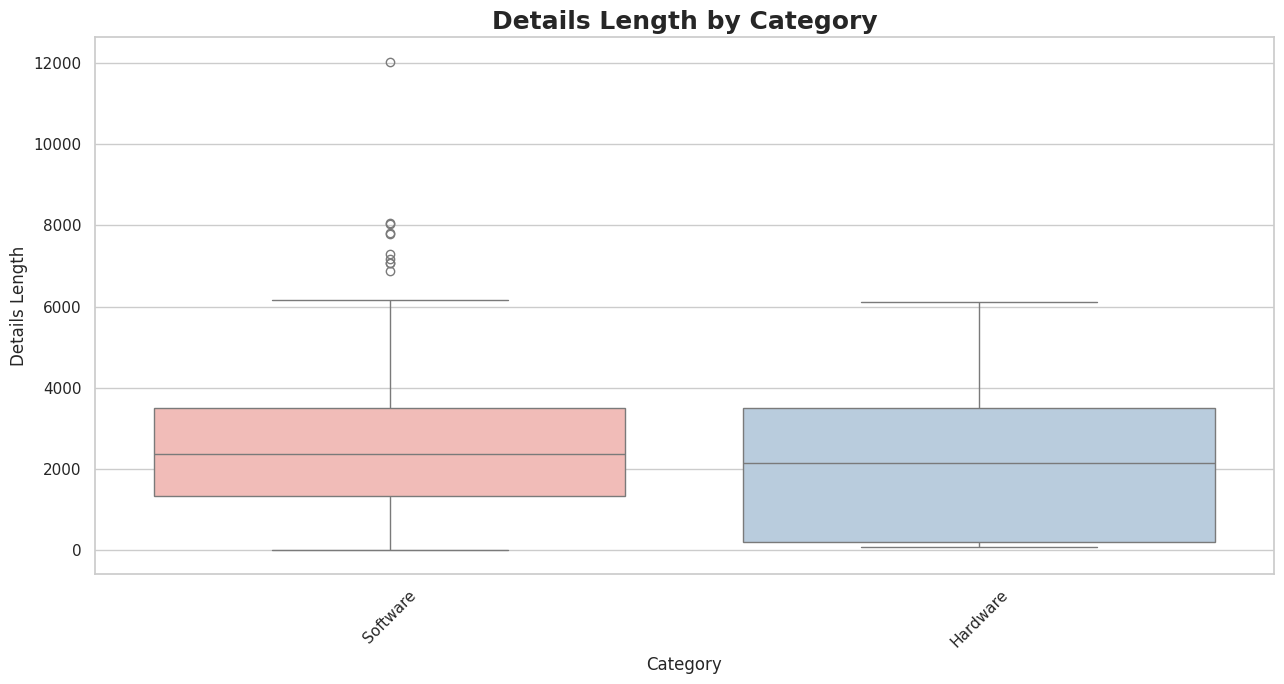

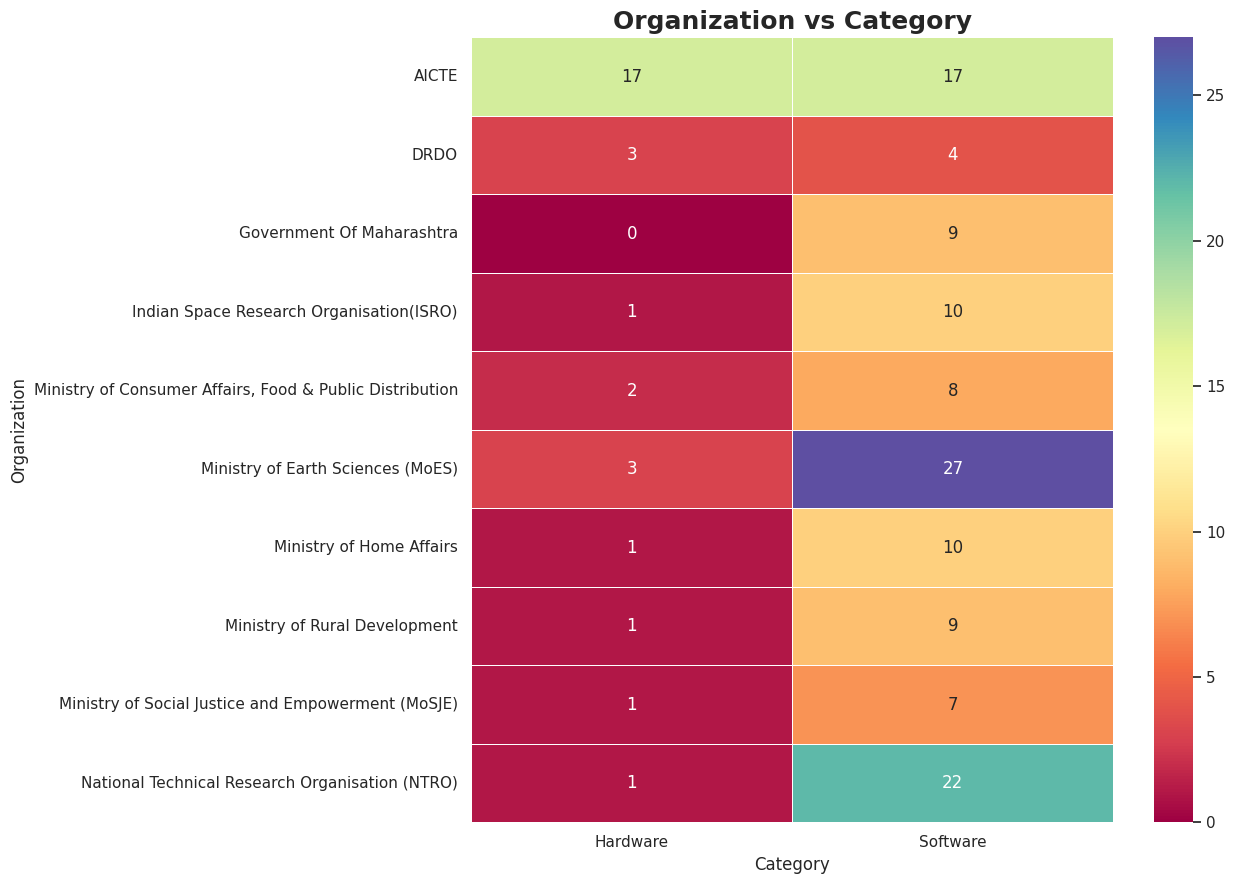

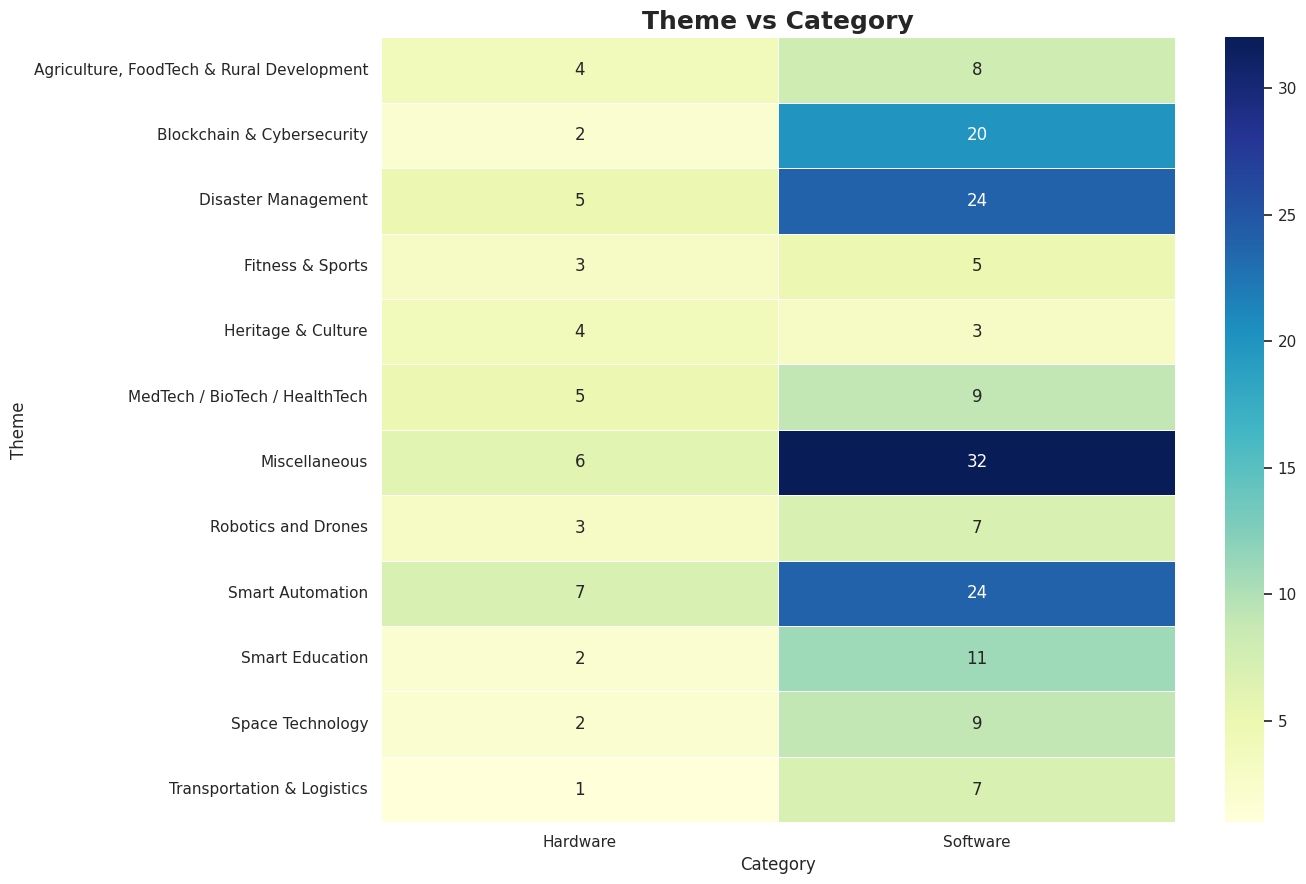

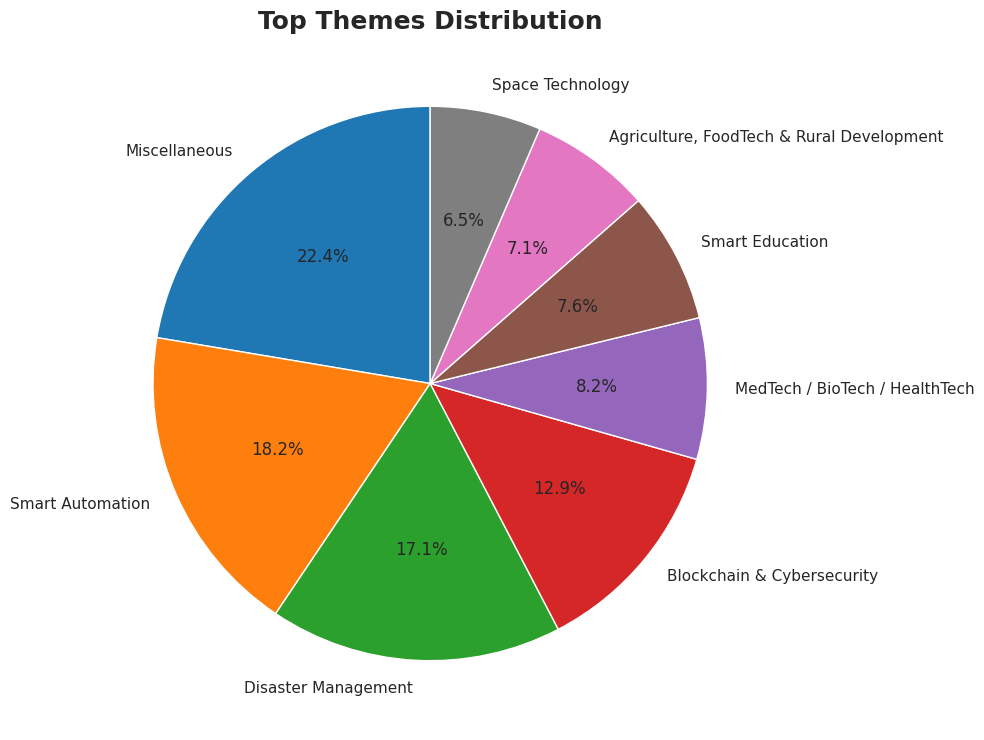

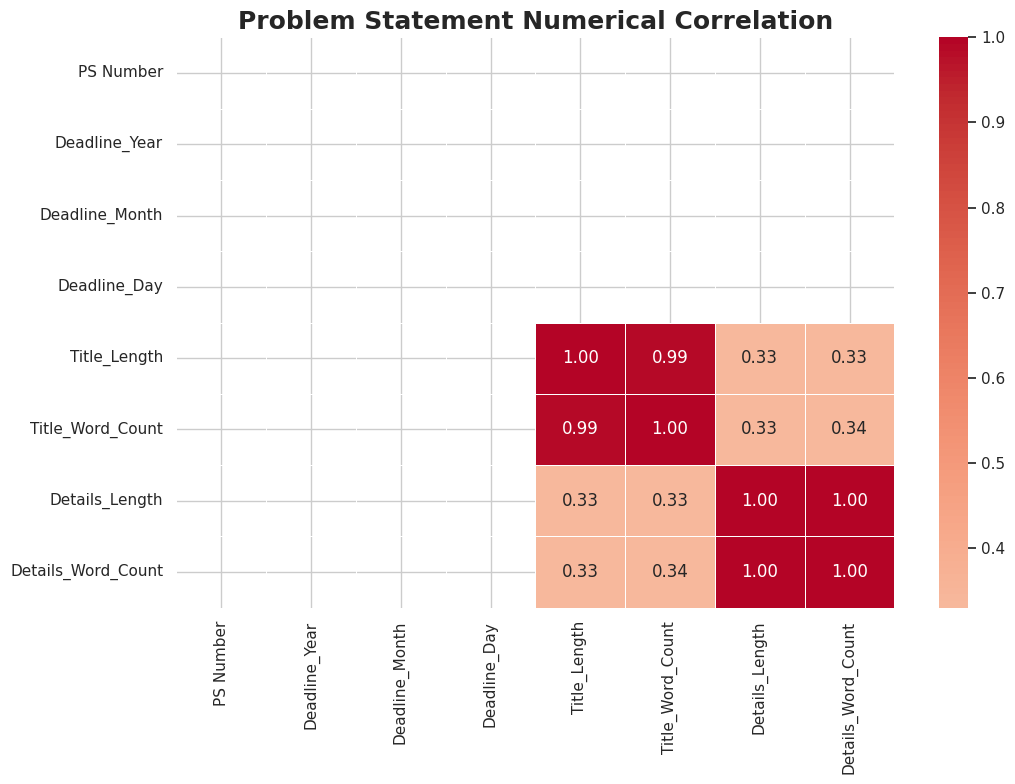

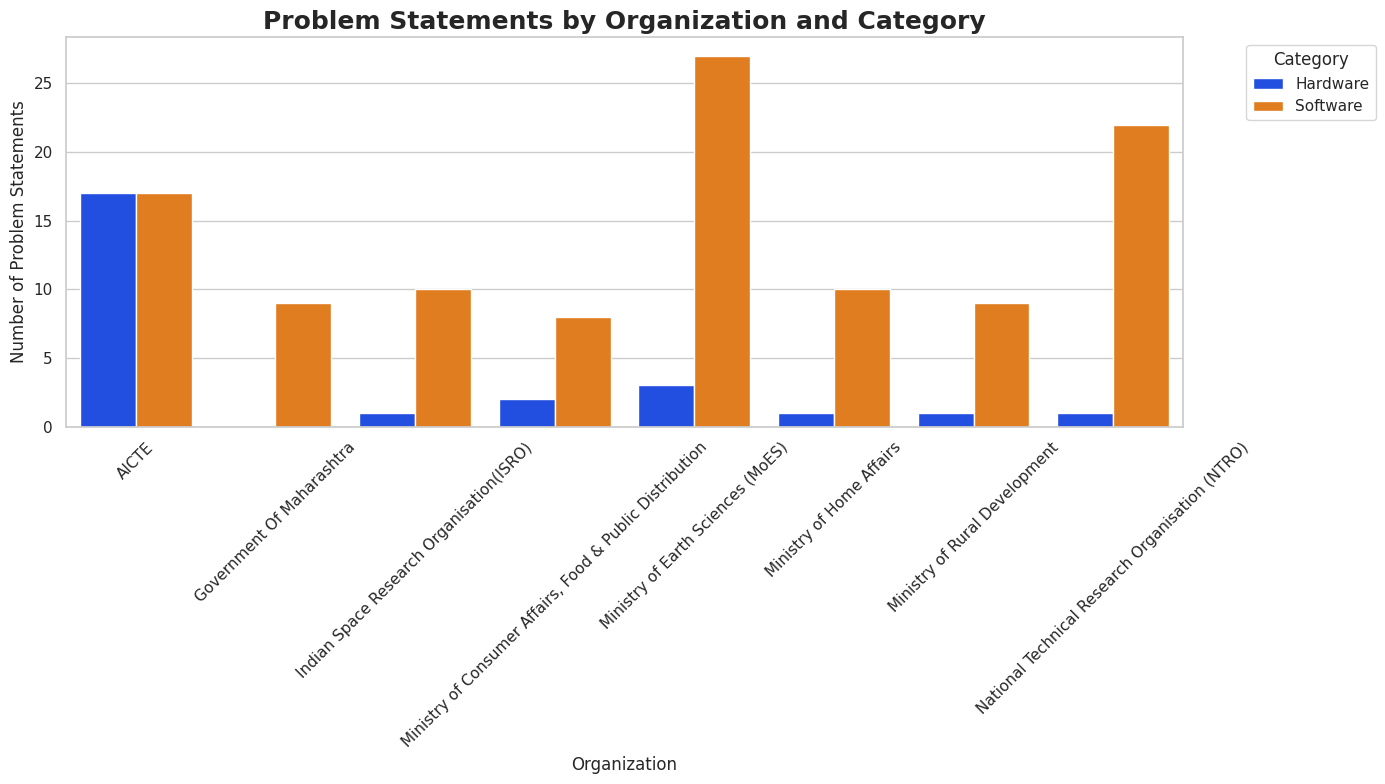


EDA COMPLETED
Final Shape: (226, 17)
Remaining NULL values: 0
Remaining duplicate rows: 0

Top Organizations:
Organization
AICTE                                                       34
Ministry of Earth Sciences (MoES)                           30
National Technical Research Organisation (NTRO)             23
Ministry of Home Affairs                                    11
Indian Space Research Organisation(ISRO)                    11
Ministry of Rural Development                               10
Ministry of Consumer Affairs, Food & Public Distribution    10
Government Of Maharashtra                                    9
Ministry of Social Justice and Empowerment (MoSJE)           8
DRDO                                                         7
Name: count, dtype: int64

Top Categories:
Category
Software    172
Hardware     54
Name: count, dtype: int64

Top Themes:
Theme
Miscellaneous                                38
Smart Automation                             31
Disaster Management  

In [12]:
# ============================================================
# PROBLEM STATEMENT DATASET - EDA & VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. COPY DATA
# ------------------------------------------------------------

data = df.copy()

# Clean column names
data.columns = data.columns.str.strip()

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())


# ============================================================
# 2. BASIC DATA CLEANING
# ============================================================

# Remove completely empty rows
data = data.dropna(how="all")

# Remove duplicate rows
print("\nDuplicate rows:", data.duplicated().sum())

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)


# ============================================================
# 3. HANDLE NULL VALUES
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES")
print("=" * 80)

print(data.isnull().sum())

# Text columns
text_columns = data.select_dtypes(
    include=["object", "category"]
).columns

for col in text_columns:

    data[col] = data[col].fillna("Unknown")


# Numeric columns
numeric_columns = data.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:

    data[col] = data[col].fillna(
        data[col].median()
    )

print("\nRemaining null values:")
print(data.isnull().sum().sum())


# ============================================================
# 4. DATE CONVERSION
# ============================================================

date_column = "Deadline for Idea Submission"

if date_column in data.columns:

    data[date_column] = pd.to_datetime(
        data[date_column],
        errors="coerce"
    )

    # Create useful date features
    data["Deadline_Year"] = (
        data[date_column].dt.year
    )

    data["Deadline_Month"] = (
        data[date_column].dt.month
    )

    data["Deadline_Month_Name"] = (
        data[date_column].dt.month_name()
    )

    data["Deadline_Day"] = (
        data[date_column].dt.day
    )

    data["Deadline_Day_Name"] = (
        data[date_column].dt.day_name()
    )


# ============================================================
# 5. PROBLEM STATEMENTS BY ORGANIZATION
# ============================================================

if "Organization" in data.columns:

    organization_count = (
        data["Organization"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=organization_count.values,
        y=organization_count.index,
        hue=organization_count.index,
        palette="viridis",
        legend=False
    )

    plt.title(
        "Top Organizations by Number of Problem Statements",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Problem Statements")
    plt.ylabel("Organization")

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. PROBLEM STATEMENTS BY CATEGORY
# ============================================================

if "Category" in data.columns:

    category_count = (
        data["Category"]
        .value_counts()
        .head(15)
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=category_count.values,
        y=category_count.index,
        hue=category_count.index,
        palette="Set2",
        legend=False
    )

    plt.title(
        "Problem Statements by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Problem Statements")
    plt.ylabel("Category")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. PROBLEM STATEMENTS BY THEME
# ============================================================

if "Theme" in data.columns:

    theme_count = (
        data["Theme"]
        .value_counts()
        .head(20)
    )

    plt.figure(figsize=(12, 8))

    sns.barplot(
        x=theme_count.values,
        y=theme_count.index,
        hue=theme_count.index,
        palette="Spectral",
        legend=False
    )

    plt.title(
        "Problem Statements by Theme",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Problem Statements")
    plt.ylabel("Theme")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. CATEGORY DISTRIBUTION - PIE CHART
# ============================================================

if "Category" in data.columns:

    category_pie = (
        data["Category"]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(9, 9))

    plt.pie(
        category_pie.values,
        labels=category_pie.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "rainbow",
            len(category_pie)
        )
    )

    plt.title(
        "Category Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 9. ORGANIZATION DISTRIBUTION - PIE CHART
# ============================================================

if "Organization" in data.columns:

    organization_pie = (
        data["Organization"]
        .value_counts()
        .head(8)
    )

    plt.figure(figsize=(9, 9))

    plt.pie(
        organization_pie.values,
        labels=organization_pie.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "Set3",
            len(organization_pie)
        )
    )

    plt.title(
        "Top Organizations Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 10. DEADLINES BY MONTH
# ============================================================

if "Deadline_Month_Name" in data.columns:

    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    monthly_deadlines = (
        data["Deadline_Month_Name"]
        .value_counts()
        .reindex(
            month_order,
            fill_value=0
        )
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=monthly_deadlines.index,
        y=monthly_deadlines.values,
        hue=monthly_deadlines.index,
        palette="coolwarm",
        legend=False
    )

    plt.title(
        "Problem Statement Deadlines by Month",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Month")
    plt.ylabel("Number of Problem Statements")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. DEADLINES BY DAY OF WEEK
# ============================================================

if "Deadline_Day_Name" in data.columns:

    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    day_count = (
        data["Deadline_Day_Name"]
        .value_counts()
        .reindex(
            day_order,
            fill_value=0
        )
    )

    plt.figure(figsize=(11, 6))

    sns.barplot(
        x=day_count.index,
        y=day_count.values,
        hue=day_count.index,
        palette="husl",
        legend=False
    )

    plt.title(
        "Problem Statement Deadlines by Day of Week",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Day")
    plt.ylabel("Number of Problem Statements")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. DEADLINE YEAR DISTRIBUTION
# ============================================================

if "Deadline_Year" in data.columns:

    year_count = (
        data["Deadline_Year"]
        .dropna()
        .value_counts()
        .sort_index()
    )

    if len(year_count) > 0:

        plt.figure(figsize=(10, 6))

        sns.barplot(
            x=year_count.index.astype(str),
            y=year_count.values,
            hue=year_count.index.astype(str),
            palette="magma",
            legend=False
        )

        plt.title(
            "Problem Statements by Deadline Year",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel("Year")
        plt.ylabel("Number of Problem Statements")

        plt.tight_layout()
        plt.show()


# ============================================================
# 13. PROBLEM STATEMENT TITLE LENGTH
# ============================================================

if "Problem Statement Title" in data.columns:

    data["Title_Length"] = (
        data["Problem Statement Title"]
        .astype(str)
        .str.len()
    )

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=data,
        x="Title_Length",
        bins=30,
        kde=True,
        color="purple"
    )

    plt.title(
        "Problem Statement Title Length Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Title Length (Characters)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. PROBLEM STATEMENT TITLE WORD COUNT
# ============================================================

if "Problem Statement Title" in data.columns:

    data["Title_Word_Count"] = (
        data["Problem Statement Title"]
        .astype(str)
        .str.split()
        .str.len()
    )

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=data,
        x="Title_Word_Count",
        bins=20,
        kde=True,
        color="orange"
    )

    plt.title(
        "Problem Statement Title Word Count",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 15. DETAILS LENGTH
# ============================================================

if "Details" in data.columns:

    data["Details_Length"] = (
        data["Details"]
        .astype(str)
        .str.len()
    )

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=data,
        x="Details_Length",
        bins=30,
        kde=True,
        color="teal"
    )

    plt.title(
        "Problem Statement Details Length",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Details Length (Characters)")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. DETAILS WORD COUNT
# ============================================================

if "Details" in data.columns:

    data["Details_Word_Count"] = (
        data["Details"]
        .astype(str)
        .str.split()
        .str.len()
    )

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=data,
        x="Details_Word_Count",
        bins=30,
        kde=True,
        color="crimson"
    )

    plt.title(
        "Problem Statement Details Word Count",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. TITLE LENGTH BY CATEGORY
# ============================================================

if (
    "Category" in data.columns
    and "Title_Length" in data.columns
):

    top_categories = (
        data["Category"]
        .value_counts()
        .head(10)
        .index
    )

    category_data = data[
        data["Category"].isin(
            top_categories
        )
    ]

    plt.figure(figsize=(13, 7))

    sns.boxplot(
        data=category_data,
        x="Category",
        y="Title_Length",
        hue="Category",
        palette="Set1",
        legend=False
    )

    plt.title(
        "Title Length by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Title Length")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. DETAILS LENGTH BY CATEGORY
# ============================================================

if (
    "Category" in data.columns
    and "Details_Length" in data.columns
):

    top_categories = (
        data["Category"]
        .value_counts()
        .head(10)
        .index
    )

    category_data = data[
        data["Category"].isin(
            top_categories
        )
    ]

    plt.figure(figsize=(13, 7))

    sns.boxplot(
        data=category_data,
        x="Category",
        y="Details_Length",
        hue="Category",
        palette="Pastel1",
        legend=False
    )

    plt.title(
        "Details Length by Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Details Length")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. CATEGORY VS ORGANIZATION HEATMAP
# ============================================================

if (
    "Organization" in data.columns
    and "Category" in data.columns
):

    top_orgs = (
        data["Organization"]
        .value_counts()
        .head(10)
        .index
    )

    top_cats = (
        data["Category"]
        .value_counts()
        .head(10)
        .index
    )

    cross_table = pd.crosstab(
        data[
            "Organization"
        ].where(
            data["Organization"].isin(
                top_orgs
            )
        ),
        data[
            "Category"
        ].where(
            data["Category"].isin(
                top_cats
            )
        )
    )

    plt.figure(figsize=(13, 9))

    sns.heatmap(
        cross_table,
        annot=True,
        fmt="d",
        cmap="Spectral",
        linewidths=0.5
    )

    plt.title(
        "Organization vs Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Organization")

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. THEME VS CATEGORY HEATMAP
# ============================================================

if (
    "Theme" in data.columns
    and "Category" in data.columns
):

    top_themes = (
        data["Theme"]
        .value_counts()
        .head(12)
        .index
    )

    top_cats = (
        data["Category"]
        .value_counts()
        .head(10)
        .index
    )

    theme_category = pd.crosstab(
        data["Theme"].where(
            data["Theme"].isin(
                top_themes
            )
        ),
        data["Category"].where(
            data["Category"].isin(
                top_cats
            )
        )
    )

    plt.figure(figsize=(14, 9))

    sns.heatmap(
        theme_category,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        linewidths=0.5
    )

    plt.title(
        "Theme vs Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Category")
    plt.ylabel("Theme")

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. TOP THEMES PIE CHART
# ============================================================

if "Theme" in data.columns:

    theme_pie = (
        data["Theme"]
        .value_counts()
        .head(8)
    )

    plt.figure(figsize=(9, 9))

    plt.pie(
        theme_pie.values,
        labels=theme_pie.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette(
            "tab10",
            len(theme_pie)
        )
    )

    plt.title(
        "Top Themes Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.show()


# ============================================================
# 22. PS NUMBER ANALYSIS
# ============================================================

if "PS Number" in data.columns:

    ps_numeric = pd.to_numeric(
        data["PS Number"],
        errors="coerce"
    )

    if ps_numeric.notna().sum() > 0:

        plt.figure(figsize=(10, 6))

        sns.histplot(
            ps_numeric.dropna(),
            bins=30,
            kde=True,
            color="blue"
        )

        plt.title(
            "Problem Statement Number Distribution",
            fontsize=18,
            fontweight="bold"
        )

        plt.xlabel("PS Number")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()


# ============================================================
# 23. NUMERICAL CORRELATION HEATMAP
# ============================================================

numeric_for_corr = [
    "PS Number",
    "Deadline_Year",
    "Deadline_Month",
    "Deadline_Day",
    "Title_Length",
    "Title_Word_Count",
    "Details_Length",
    "Details_Word_Count"
]

available_corr = [
    col
    for col in numeric_for_corr
    if col in data.columns
]

if len(available_corr) >= 2:

    numeric_data = data[
        available_corr
    ].copy()

    # Convert everything to numeric safely
    for col in numeric_data.columns:

        numeric_data[col] = pd.to_numeric(
            numeric_data[col],
            errors="coerce"
        )

    correlation = numeric_data.corr()

    plt.figure(figsize=(11, 8))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(
        "Problem Statement Numerical Correlation",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. TOP ORGANIZATIONS + CATEGORIES
# ============================================================

if (
    "Organization" in data.columns
    and "Category" in data.columns
):

    top_orgs = (
        data["Organization"]
        .value_counts()
        .head(8)
        .index
    )

    organization_category = (
        data[
            data["Organization"].isin(
                top_orgs
            )
        ]
        .groupby(
            ["Organization", "Category"]
        )
        .size()
        .reset_index(
            name="Count"
        )
    )

    plt.figure(figsize=(14, 8))

    sns.barplot(
        data=organization_category,
        x="Organization",
        y="Count",
        hue="Category",
        palette="bright"
    )

    plt.title(
        "Problem Statements by Organization and Category",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Organization")
    plt.ylabel("Number of Problem Statements")

    plt.xticks(rotation=45)

    plt.legend(
        title="Category",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("EDA COMPLETED")
print("=" * 80)

print("Final Shape:", data.shape)

print(
    "Remaining NULL values:",
    data.isnull().sum().sum()
)

print(
    "Remaining duplicate rows:",
    data.duplicated().sum()
)

print("\nTop Organizations:")
print(
    data["Organization"]
    .value_counts()
    .head(10)
)

print("\nTop Categories:")
print(
    data["Category"]
    .value_counts()
    .head(10)
)

print("\nTop Themes:")
print(
    data["Theme"]
    .value_counts()
    .head(10)
)

print("\nVisualization completed successfully! ✓")

## Features Engineering

ORIGINAL DATA
Shape: (226, 8)
['Unnamed: 0', 'Organization', 'Problem Statement Title', 'Category', 'PS Number', 'Theme', 'Deadline for Idea Submission', 'Details']

Duplicate rows: 0
Shape after removing duplicates: (226, 8)

NULL VALUES BEFORE HANDLING
Unnamed: 0                      0
Organization                    0
Problem Statement Title         0
Category                        0
PS Number                       0
Theme                           0
Deadline for Idea Submission    0
Details                         0
dtype: int64

FEATURE ENGINEERING COMPLETED
New columns:
✓ Deadline_Year
✓ Deadline_Month
✓ Deadline_Day
✓ Deadline_DayOfWeek
✓ Deadline_Quarter
✓ Deadline_IsWeekend
✓ Title_Length
✓ Title_Word_Count
✓ Title_Unique_Words
✓ Details_Length
✓ Details_Word_Count
✓ PS_Number_Numeric

FEATURE INFORMATION
Numerical features:
['Deadline_Year', 'Deadline_Month', 'Deadline_Day', 'Deadline_DayOfWeek', 'Deadline_Quarter', 'Deadline_IsWeekend', 'Title_Length', 'Title_Word_Count', '

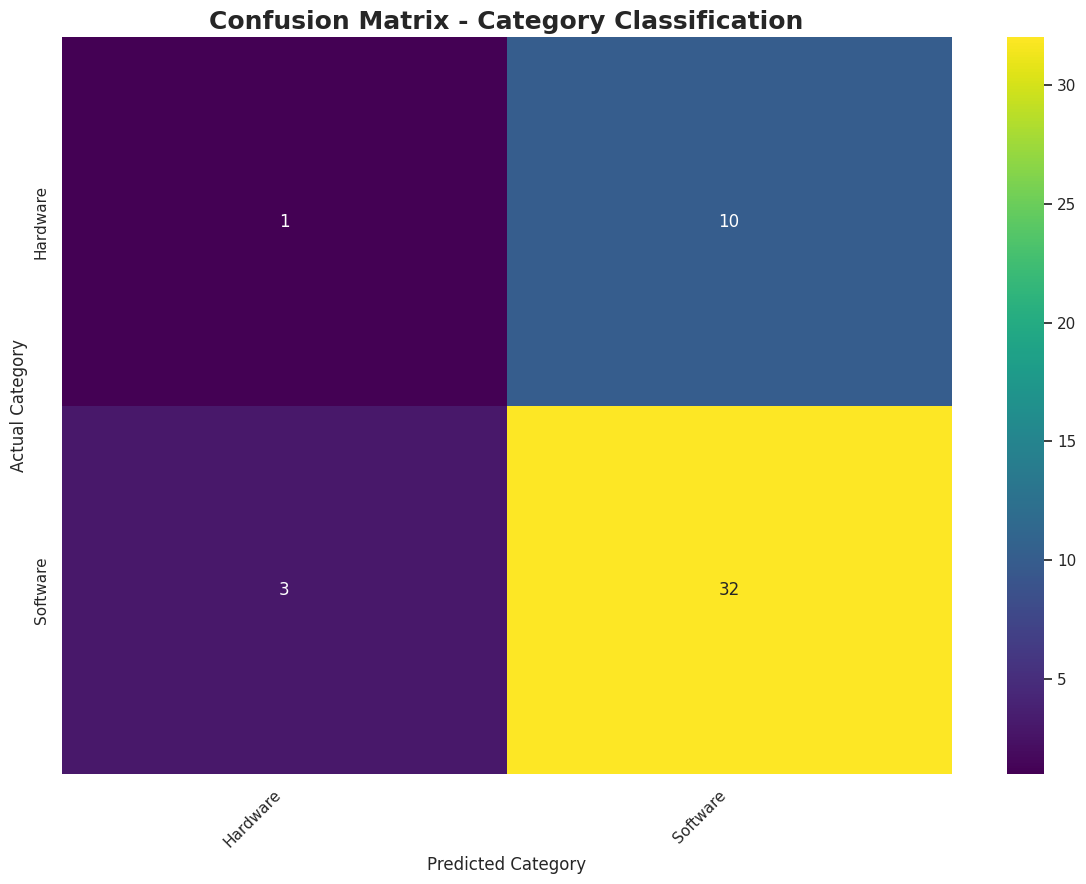

<Figure size 1300x700 with 0 Axes>

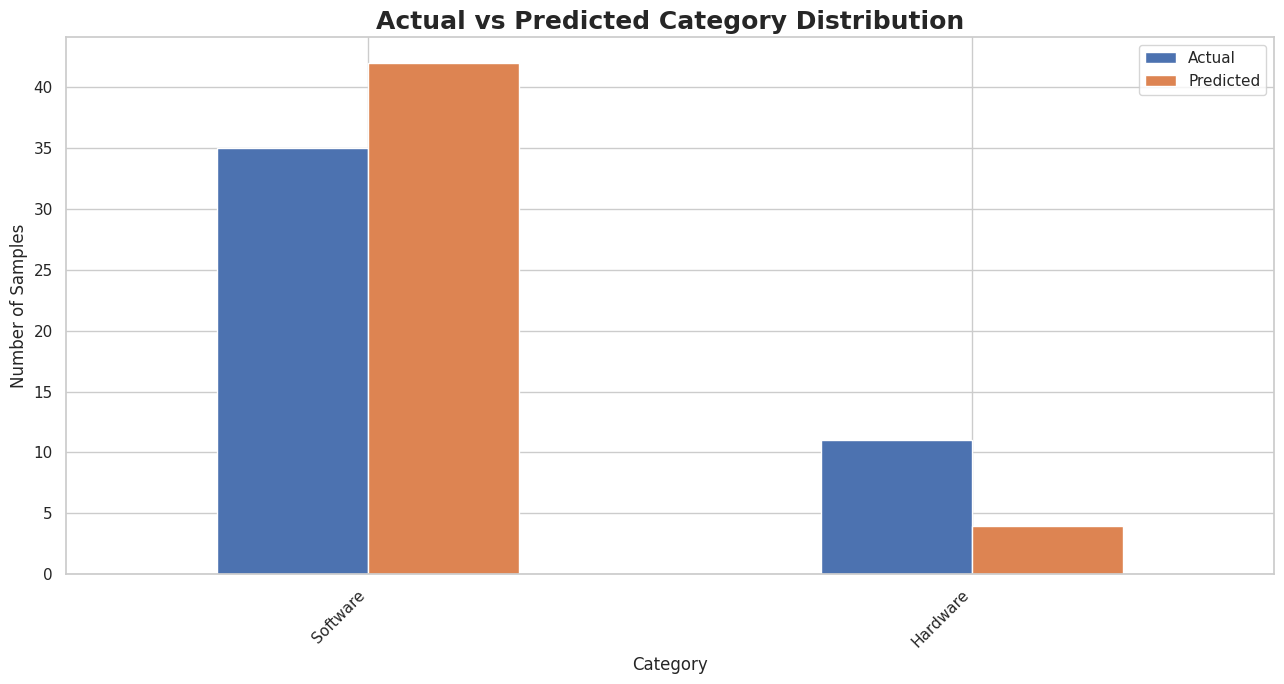


FEATURE IMPORTANCE
                                                                     Feature  Importance
                                                     numeric__Details_Length    0.133002
                                                       numeric__Title_Length    0.128555
                                                 numeric__Details_Word_Count    0.126402
                                                 numeric__Title_Unique_Words    0.094912
                                                   numeric__Title_Word_Count    0.093659
   categorical__Organization_National Technical Research Organisation (NTRO)    0.019295
                                         categorical__Theme_Smart Automation    0.019193
                                      categorical__Organization_Qualcomm Inc    0.019162
                                  categorical__Organization_Ministry of MSME    0.017926
                                            categorical__Theme_Miscellaneous    0.017024
 

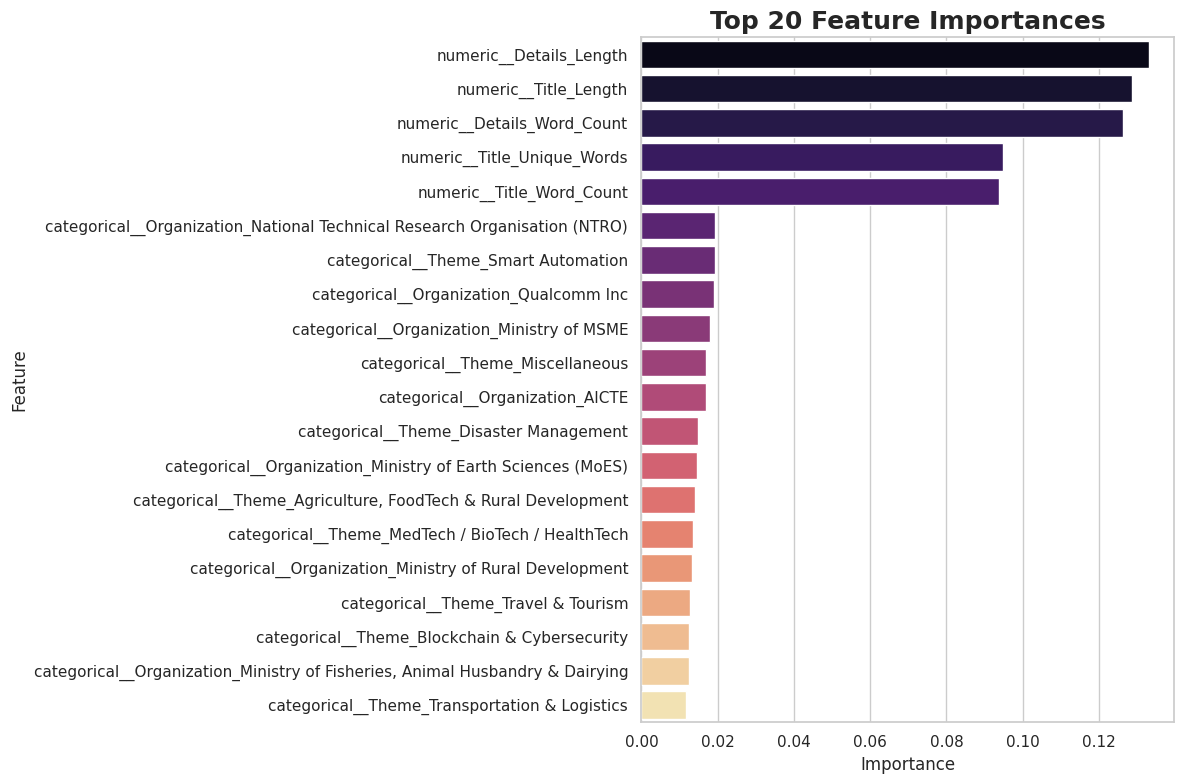


FINAL MODEL SUMMARY
Dataset shape: (226, 20)
Training samples: 180
Testing samples: 46
Number of input features: 14
Accuracy: 71.74%

Classification completed successfully ✓


In [13]:
# ============================================================
# PROBLEM STATEMENT DATASET
# FEATURE ENGINEERING + TRAIN TEST + CLASSIFICATION + ACCURACY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. COPY DATA
# ============================================================

data = df.copy()

print("=" * 80)
print("ORIGINAL DATA")
print("=" * 80)

print("Shape:", data.shape)
print(data.columns.tolist())


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

data.columns = data.columns.str.strip()


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

print("\nDuplicate rows:", data.duplicated().sum())

data = data.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", data.shape)


# ============================================================
# 4. HANDLE NULL VALUES
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES BEFORE HANDLING")
print("=" * 80)

print(data.isnull().sum())


# Text columns
text_cols = data.select_dtypes(
    include=["object", "category"]
).columns

for col in text_cols:
    data[col] = data[col].fillna("Unknown")


# Numeric columns
numeric_cols = data.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    data[col] = data[col].fillna(
        data[col].median()
    )


# ============================================================
# 5. DATE FEATURE ENGINEERING
# ============================================================

date_col = "Deadline for Idea Submission"

if date_col in data.columns:

    data[date_col] = pd.to_datetime(
        data[date_col],
        errors="coerce"
    )

    # Fill invalid/missing dates using most common date
    if data[date_col].notna().sum() > 0:
        median_date = data[date_col].dropna().sort_values().iloc[
            len(data[date_col].dropna()) // 2
        ]
        data[date_col] = data[date_col].fillna(
            median_date
        )

    data["Deadline_Year"] = (
        data[date_col].dt.year
    )

    data["Deadline_Month"] = (
        data[date_col].dt.month
    )

    data["Deadline_Day"] = (
        data[date_col].dt.day
    )

    data["Deadline_DayOfWeek"] = (
        data[date_col].dt.dayofweek
    )

    data["Deadline_Quarter"] = (
        data[date_col].dt.quarter
    )

    data["Deadline_IsWeekend"] = (
        data["Deadline_DayOfWeek"] >= 5
    ).astype(int)


# ============================================================
# 6. TITLE FEATURE ENGINEERING
# ============================================================

if "Problem Statement Title" in data.columns:

    data["Title_Length"] = (
        data["Problem Statement Title"]
        .astype(str)
        .str.len()
    )

    data["Title_Word_Count"] = (
        data["Problem Statement Title"]
        .astype(str)
        .str.split()
        .str.len()
    )

    data["Title_Unique_Words"] = (
        data["Problem Statement Title"]
        .astype(str)
        .apply(
            lambda x: len(
                set(x.lower().split())
            )
        )
    )


# ============================================================
# 7. DETAILS FEATURE ENGINEERING
# ============================================================

if "Details" in data.columns:

    data["Details_Length"] = (
        data["Details"]
        .astype(str)
        .str.len()
    )

    data["Details_Word_Count"] = (
        data["Details"]
        .astype(str)
        .str.split()
        .str.len()
    )


# ============================================================
# 8. PS NUMBER CONVERSION
# ============================================================

if "PS Number" in data.columns:

    data["PS_Number_Numeric"] = pd.to_numeric(
        data["PS Number"],
        errors="coerce"
    )

    data["PS_Number_Numeric"] = (
        data["PS_Number_Numeric"]
        .fillna(
            data["PS_Number_Numeric"].median()
        )
    )


# ============================================================
# 9. SHOW FEATURE ENGINEERING RESULT
# ============================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 80)

print("New columns:")

new_features = [
    "Deadline_Year",
    "Deadline_Month",
    "Deadline_Day",
    "Deadline_DayOfWeek",
    "Deadline_Quarter",
    "Deadline_IsWeekend",
    "Title_Length",
    "Title_Word_Count",
    "Title_Unique_Words",
    "Details_Length",
    "Details_Word_Count",
    "PS_Number_Numeric"
]

for col in new_features:
    if col in data.columns:
        print("✓", col)


# ============================================================
# 10. TARGET
# ============================================================

target = "Category"

if target not in data.columns:
    raise ValueError(
        "Category column is not present in the dataset."
    )


# Remove rows where target is missing/unknown
data[target] = data[target].astype(str)

data = data[
    data[target].str.strip() != ""
].copy()


# ============================================================
# 11. REMOVE COLUMNS THAT SHOULD NOT BE USED
# ============================================================

# We intentionally remove:
# - Category -> target
# - Details -> raw text
# - Problem Statement Title -> raw text
# - Deadline date -> replaced with engineered features
# - PS Number -> replaced with numeric feature
# - IDs/index-like fields
#
# This keeps the model focused on useful structured features.

drop_columns = [
    target,
    "Details",
    "Problem Statement Title",
    "Deadline for Idea Submission",
    "PS Number",
    "Unnamed: 0"
]

drop_columns = [
    col for col in drop_columns
    if col in data.columns
]


X = data.drop(
    columns=drop_columns
)

y = data[target]


# ============================================================
# 12. REMOVE HIGH-CARDINALITY IDENTIFIER COLUMNS
# ============================================================

# ID-like columns generally do not provide meaningful
# predictive information and can cause overfitting.

identifier_columns = []

for col in X.columns:

    col_lower = col.lower()

    if (
        col_lower.endswith("id")
        or col_lower in [
            "id",
            "record_id"
        ]
    ):
        identifier_columns.append(col)

if identifier_columns:

    print("\nRemoving ID columns:")
    print(identifier_columns)

    X = X.drop(
        columns=identifier_columns
    )


# ============================================================
# 13. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\n" + "=" * 80)
print("FEATURE INFORMATION")
print("=" * 80)

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal features:", X.shape[1])


# ============================================================
# 14. REMOVE VERY HIGH-CARDINALITY TEXT COLUMNS
# ============================================================

# Columns such as long free-text fields are not suitable
# for simple one-hot encoding.

high_cardinality_columns = []

for col in categorical_features:

    unique_ratio = (
        X[col].nunique(dropna=False)
        / len(X)
    )

    if unique_ratio > 0.50:

        high_cardinality_columns.append(col)


if high_cardinality_columns:

    print(
        "\nRemoving high-cardinality columns:"
    )

    print(
        high_cardinality_columns
    )

    X = X.drop(
        columns=high_cardinality_columns
    )

    categorical_features = [
        col for col in categorical_features
        if col not in high_cardinality_columns
    ]


# ============================================================
# 15. TRAIN TEST SPLIT
# ============================================================

print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

# Check class distribution
class_counts = y.value_counts()

print("\nClass distribution:")
print(class_counts)


# Stratification is useful only when every class
# has at least 2 observations.

if len(class_counts) > 1 and class_counts.min() >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    print(
        "\nWarning: Some classes have fewer than 2 samples."
    )

    print(
        "Using train_test_split without stratification."
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )


print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 16. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),

        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 17. RANDOM FOREST CLASSIFIER
# ============================================================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


# ============================================================
# 18. COMPLETE PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "classifier",
            model
        )
    ]
)


# ============================================================
# 19. TRAIN MODEL
# ============================================================

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

pipeline.fit(
    X_train,
    y_train
)

print("Training completed successfully ✓")


# ============================================================
# 20. PREDICTION
# ============================================================

y_pred = pipeline.predict(
    X_test
)


# ============================================================
# 21. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n" + "=" * 80)
print("MODEL ACCURACY")
print("=" * 80)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy Percentage: {accuracy * 100:.2f}%"
)


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 23. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=pipeline.classes_
)

plt.figure(
    figsize=(12, 9)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=pipeline.classes_,
    yticklabels=pipeline.classes_
)

plt.title(
    "Confusion Matrix - Category Classification",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Category"
)

plt.ylabel(
    "Actual Category"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 24. ACTUAL VS PREDICTED DISTRIBUTION
# ============================================================

actual_counts = (
    pd.Series(y_test)
    .value_counts()
)

predicted_counts = (
    pd.Series(y_pred)
    .value_counts()
)

comparison = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
}).fillna(0)


plt.figure(
    figsize=(13, 7)
)

comparison.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title(
    "Actual vs Predicted Category Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Number of Samples")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ============================================================
# 25. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

try:

    # Get transformed feature names
    feature_names = (
        pipeline
        .named_steps["preprocessing"]
        .get_feature_names_out()
    )

    importances = (
        pipeline
        .named_steps["classifier"]
        .feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })

    feature_importance = (
        feature_importance
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(20)
    )

    print(
        feature_importance.to_string(
            index=False
        )
    )


    # Visualization
    plt.figure(
        figsize=(12, 8)
    )

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="magma",
        legend=False
    )

    plt.title(
        "Top 20 Feature Importances",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()
    plt.show()

except Exception as e:

    print(
        "Feature importance could not be displayed:"
    )

    print(e)


# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FINAL MODEL SUMMARY")
print("=" * 80)

print(
    "Dataset shape:",
    data.shape
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

print(
    "Number of input features:",
    X.shape[1]
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

print(
    "\nClassification completed successfully ✓"
)

## Thanks......Please Upvote